<a href="https://colab.research.google.com/github/J-Eisenhauer/bern2/blob/main/unsupervised_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Jakob Eisenhauer

# BERN02 lab: Unsupervised learning

**Dimension reduction (SVD / PCA) and clustering, with a spectroscopy example**

This lab accompanies the lecture on unsupervised learning (ISL chapter 12.1–12.2 and 12.4).
You will

1. explore a small, well known dataset (iris) and learn why **scaling** changes the answer,
2. compute a **singular value decomposition (SVD)** by hand and understand what the pieces mean,
3. see PCA as a **rotation of the coordinate system** that minimises the unexplained variance,
4. apply SVD to a **simulated transient-absorption experiment** (GS → A → B → C → GS) and discover what SVD can and cannot tell you about the chemistry,
5. cluster with **k-means** and **hierarchical clustering**, and learn to pick the number of clusters with the **elbow** and **silhouette** criteria,
6. discover on the **smiley point clouds** why the choice of algorithm matters (k-means vs DBSCAN vs spectral clustering),
7. (bonus) compare linear and non-linear embeddings (PCA vs t-SNE) on handwritten digits.

Cells marked **Task** expect you to write code. In the student version the code cells contain `# your code here`.
A reference solution is in `unsupervised_learning_solved.ipynb` – try first, peek later.

> **Convention used throughout:** a data matrix `X` has one **observation per row** and one **feature (variable) per column**,
> exactly like a pandas DataFrame. Keep this in mind whenever you look at the shapes of `U`, `S` and `Vt`.


In [ ]:
# --- Setup: run this cell first ------------------------------------------------
# Everything below is in the standard scientific Python stack (Anaconda) and on Google Colab.
import sys, os, pathlib, warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="Graph is not fully connected")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats
import scipy.cluster.hierarchy as sch      # dendrograms and linkage
from scipy.optimize import least_squares

import sklearn.datasets
import sklearn.cluster
import sklearn.decomposition
import sklearn.preprocessing
import sklearn.metrics
import sklearn.manifold

import skimage.io, skimage.color, skimage.filters   # image handling (replaces cv2)

%matplotlib inline
plt.rcParams["figure.dpi"] = 100
sns.set_context("notebook")

RNG_SEED = 12345                 # one seed for the whole notebook -> reproducible figures
np.random.seed(RNG_SEED)

# Where are the smiley images?  In the course repo they live in ./Smileys, in the project upload in ./sources
SMILEY_DIR = next((p for p in [pathlib.Path("Smileys"), pathlib.Path("sources"), pathlib.Path("../Smileys")] if p.exists()), None)
print("python", sys.version.split()[0], "| numpy", np.__version__, "| pandas", pd.__version__, "| sklearn", sklearn.__version__)
print("Smiley images found in:", SMILEY_DIR)


python 3.13.15 | numpy 2.1.3 | pandas 2.2.3 | sklearn 1.6.1
Smiley images found in: None


Importing Smileys from GitHub directly.

In [ ]:
import urllib.request

BASE = "https://raw.githubusercontent.com/luchem/bern02/main/Labs/unsupervised/Smileys/"
files = ["NdFeB-Domains.jpg"] + [f"{p}_{i}_o.png" for p in ("cl", "bl") for i in range(1, 5)]

pathlib.Path("Smileys").mkdir(exist_ok=True)
for f in files:
    target = pathlib.Path("Smileys") / f
    urllib.request.urlretrieve(BASE + f, target)

SMILEY_DIR = pathlib.Path("Smileys")      # overrides what the Setup cell found (None)
print(sorted(p.name for p in SMILEY_DIR.iterdir()))

['NdFeB-Domains.jpg', 'bl_1_o.png', 'bl_2_o.png', 'bl_3_o.png', 'bl_4_o.png', 'cl_1_o.png', 'cl_2_o.png', 'cl_3_o.png', 'cl_4_o.png']


# Part 1 – Getting to know the data

We use the **iris** dataset that ships with scikit-learn: 150 flowers, 4 measured lengths in cm, 3 species.
The species labels exist, but we will **not** use them for learning – only for checking how well the unsupervised
methods rediscover them. That is the usual situation in the lab: you measure many samples and hope the structure
you find corresponds to something real.


In [ ]:
iris = sklearn.datasets.load_iris()
df_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
species = pd.Series(iris.target_names[iris.target], name="species")    # human readable labels, used only for colouring
df_iris.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## Task 1.1 – explore
* Read the description: `print(iris['DESCR'])`.
* Look at `df_iris.describe()`: what are the means and standard deviations of the four columns? Which column varies most?
* Use `sns.pairplot(...)` on the DataFrame (add the species as `hue`) to inspect the relations between the columns.
  Which pairs of variables are strongly correlated? Which single variable separates the species best by eye?


.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


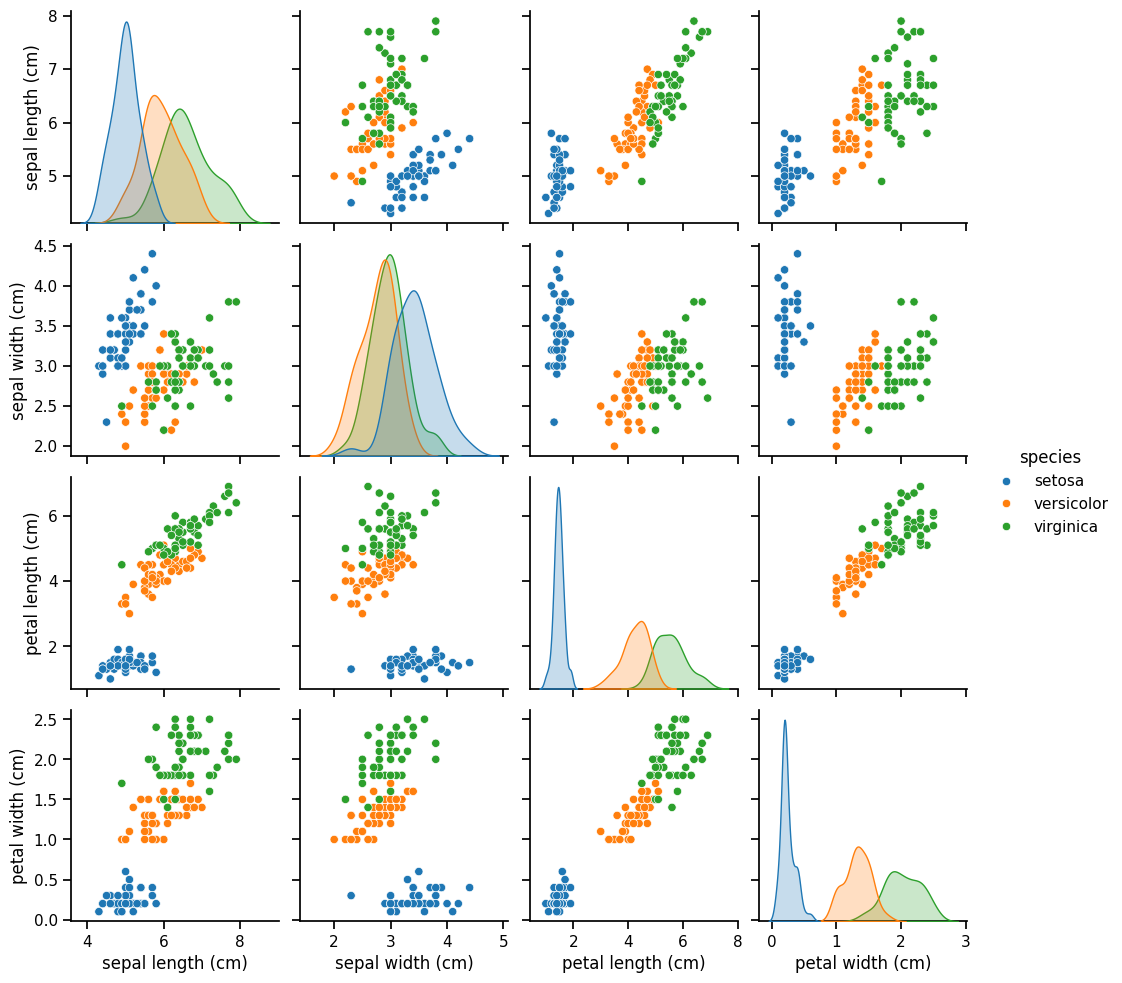

In [ ]:
print(iris['DESCR']) # description of dataset

display(df_iris.describe()) #mean, std per col

sns.pairplot(df_iris.assign(species=species), hue="species")
# .assign(species=species) adds the species as a temporary extra column
# so that hue can colour by it
plt.show()

**What you should have seen.** Petal length and petal width are almost perfectly correlated (r ≈ 0.96): the data
are essentially lower dimensional than four. The petal variables separate the species; the sepal width does not.
Note also that petal length has a standard deviation of 1.8 cm while petal width has 0.8 cm and sepal width 0.4 cm.
Any method based on distances or variances will weigh the variables by these numbers – **unless we scale first**.


# Part 2 – Singular value decomposition and PCA

Singular value decomposition factorises any real matrix $X \in \mathbb{R}^{m\times n}$ into

$$X = U\,\Sigma\,V^T$$

* $U \in \mathbb{R}^{m\times m}$ – the **left singular vectors**; the columns are orthonormal eigenvectors of $XX^T$.
  With our convention (rows = observations) these are patterns *over the observations*.
* $\Sigma$ – diagonal, with the non-negative **singular values** $s_1 \ge s_2 \ge \dots$ on the diagonal.
* $V \in \mathbb{R}^{n\times n}$ – the **right singular vectors**; the columns are orthonormal eigenvectors of $X^TX$.
  These are patterns *over the features*, i.e. the directions in feature space.

`np.linalg.svd(X, full_matrices=False)` returns `U` (m×k), `S` (k,) and `Vt` = $V^T$ (k×n) with $k=\min(m,n)$.

**Connection to PCA.** If the columns of $X$ are centred (mean zero), the covariance matrix is
$C = \frac{1}{m-1}X^TX = \frac{1}{m-1} V\Sigma^2V^T$. So the right singular vectors *are* the principal component
loadings, and the eigenvalues of $C$ – the variances along the principal components – are $\lambda_j = s_j^2/(m-1)$.
The **scores** (the coordinates of every observation in the new system) are $Z = XV = U\Sigma$.

The **proportion of variance explained** (ISL eq. 12.8 and 12.9) by component $j$ is therefore

$$\mathrm{PVE}_j = \frac{s_j^2}{\sum_k s_k^2}.$$


## Task 2.1 – SVD on raw, centred and standardised data

Compute the SVD of the iris matrix three times:

1. on the raw data `df_iris.values`,
2. on the **centred** data (subtract the column means),
3. on the **standardised** data (subtract mean, divide by standard deviation; `sklearn.preprocessing.StandardScaler` does this).

For each case print the singular values and the PVE of every component. Then plot the cumulative PVE against the
number of components for the three cases in one figure. Label the axes using the ISL terminology.
What is $\sum_k s_k^2$ in each case, and what does that number mean? (Hint: for standardised data it is a nice
number related to the shape of the matrix – check whether your scaler divides by $m$ or $m-1$.)


raw           shapes U(150, 4) S(4,) Vt(4, 4)
              singular values: [95.96  17.761  3.461  1.885]
              PVE: [9.653e-01 3.310e-02 1.300e-03 4.000e-04] | sum of s^2 = 9539.29
centred       shapes U(150, 4) S(4,) Vt(4, 4)
              singular values: [25.1    6.013  3.414  1.885]
              PVE: [0.9246 0.0531 0.0171 0.0052] | sum of s^2 = 681.37
standardised  shapes U(150, 4) S(4,) Vt(4, 4)
              singular values: [20.923 11.709  4.692  1.763]
              PVE: [0.7296 0.2285 0.0367 0.0052] | sum of s^2 = 600.0


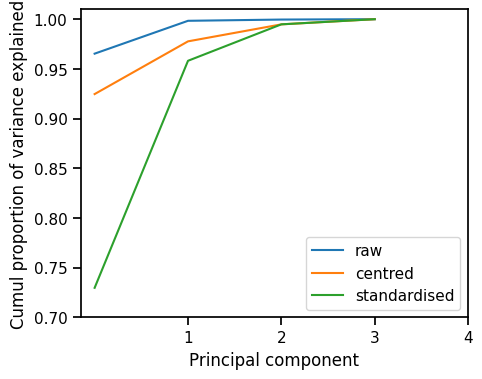

In [ ]:
# your code here

X_raw = df_iris.values
X_cen = X_raw - X_raw.mean(axis=0)
X_std = sklearn.preprocessing.StandardScaler().fit_transform(X_raw)

cases = {"raw": X_raw,
         "centred": X_cen,
         "standardised": X_std}

SVD_results = {}

fig, ax = plt.subplots(figsize=(5, 4))
for name, X in cases.items():
    U, S, Vt = np.linalg.svd(X, full_matrices=False)
    SVD_results[name] = (U, S, Vt)
    PVE = S**2 / (S**2).sum()
    print(f"{name:13s} shapes U{U.shape} S{S.shape} Vt{Vt.shape}")
    print(f"{'':13s} singular values:", S.round(3))
    print(f"{'':13s} PVE:", PVE.round(4), "| sum of s^2 =", round(np.sum(S**2), 2))
    ax.plot(PVE.cumsum(), label=name)
ax.set(xlabel="Principal component", ylabel="Cumul proportion of variance explained",
       xticks=range(1, 5), ylim=(0.7, 1.01))
ax.legend()
plt.show()


**Discussion.**
* On the **raw** data the first singular value is huge and the first "component" explains 97 % – but that
  component is essentially the mean flower. The "variance" it explains is the offset from zero, not a variation
  between flowers. This is why PCA always centres the data (and why `np.linalg.svd(df_iris)` alone is *not* PCA).
* For **centred** data $\sum s_k^2 = (m-1)\sum_j \mathrm{Var}(x_j) = 149 \times 4.57 \approx 681$: the total variance.
  The first two components explain 98 %, but petal length dominates because it has the largest variance in cm.
* For **standardised** data every column has variance 1, so $\sum s_k^2 = m\times p = 150\times 4 = 600$
  (scikit-learn's `StandardScaler` divides by the population standard deviation, `ddof=0`; with pandas' `std()`,
  `ddof=1`, you get $(m-1)p = 596$ – be aware which one you use). Now the first two components explain "only" 96 % –
  but each variable had the same right to contribute.

Whether to scale is a **scientific** decision, not a technical one: if all columns are the same physical quantity
(e.g. absorbance at different wavelengths) you usually should *not* scale, because the variance carries information.
If the columns are apples and oranges (cm, kg, pH) you must scale, otherwise the unit choice decides the result.


## Task 2.2 – scores and loadings

Use the SVD of the **standardised** data. The scores $Z = U\Sigma$ are the coordinates of each flower in the
principal-component system.

* Make a scatter plot of the first two scores, coloured by species (the labels are only for colouring).
* Next to it plot the same for the original first two columns of the data, and for the scores 3 and 4.
  Which representation separates the species best?
* Print `Vt[0]` and `Vt[1]` (the loadings) with the feature names. Which variables make up the first component?
  Interpret the sign pattern of the second component.


Vt = loadings: how the new axes are built from the original variables. Each row is one axis, and its entries are the weights of the four measurements.

S = singular values: how much variation each axis explains.

Z = U * S = scores: the new coordinates of each data point in the PC system. It is the result of the transformation, not the transformation itself.

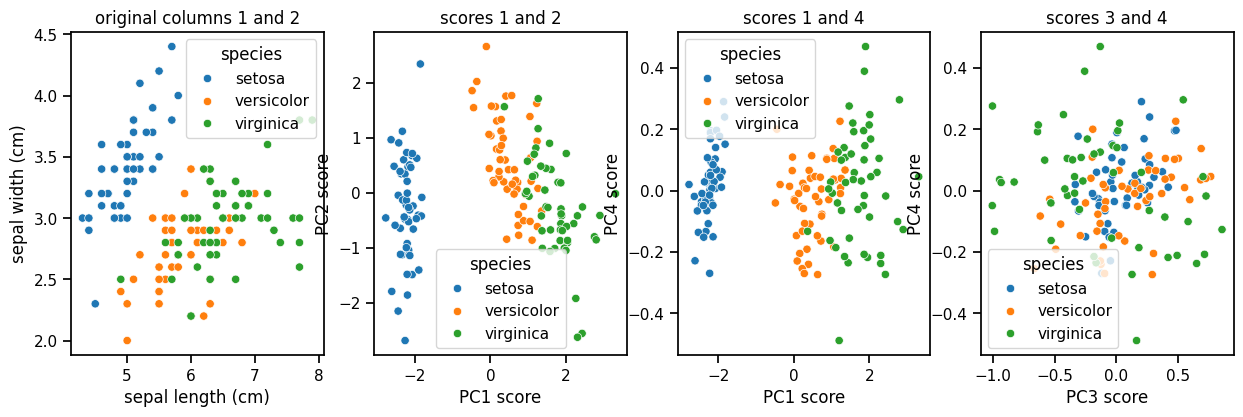

Vt[0] = [ 0.52106591 -0.26934744  0.5804131   0.56485654]
Vt[1] = [-0.37741762 -0.92329566 -0.02449161 -0.06694199]
Vt[2] = [ 0.71956635 -0.24438178 -0.14212637 -0.63427274]
Vt[3] = [ 0.26128628 -0.12350962 -0.80144925  0.52359713]


In [ ]:
# your code here

U, S, Vt = SVD_results["standardised"]
Z = U @ np.diag(S)
fig, ax = plt.subplots(1, 4, figsize=(15, 4.2))

sns.scatterplot(x=df_iris.iloc[:, 0], y=df_iris.iloc[:, 1], hue=species, ax=ax[0])
ax[0].set(title="original columns 1 and 2")

sns.scatterplot(x=Z[:, 0], y=Z[:, 1], hue=species, ax=ax[1])
ax[1].set(xlabel="PC1 score", ylabel="PC2 score", title="scores 1 and 2")

sns.scatterplot(x=Z[:,0], y=Z[:,3], hue=species, ax=ax[2])
ax[2].set(xlabel="PC1 score", ylabel="PC4 score", title="scores 1 and 4")

sns.scatterplot(x=Z[:, 2], y=Z[:, 3], hue=species, ax=ax[3])
ax[3].set(xlabel="PC3 score", ylabel="PC4 score", title="scores 3 and 4")


plt.show()

print("Vt[0] =", Vt[0])
print("Vt[1] =", Vt[1])
print("Vt[2] =", Vt[2])
print("Vt[3] =", Vt[3])

**Reading the loadings.** PC1 is a weighted sum of petal length, petal width and sepal length with the same sign,
minus sepal width: "big flower with narrow sepals". PC2 is almost pure sepal width. The scores on PC3 and PC4 are
small and show no species structure – that is the 4 % of variance we can drop.

The signs of singular vectors are **arbitrary** (flip $u_j$ and $v_j$ together and nothing changes). Do not
over-interpret a sign, only sign *patterns* within one vector.


# Part 3 – PCA as a rotation of the axes

To see what the first principal component *is*, we reduce the problem to two dimensions: petal length and petal width
of the two similar species *versicolor* and *virginica*. In two dimensions a principal component is nothing more than
a rotation of the coordinate system by an angle $\alpha$:

$$\begin{bmatrix} x' \\ y' \end{bmatrix} = \begin{bmatrix} \cos\alpha & \sin\alpha \\ -\sin\alpha & \cos\alpha\end{bmatrix} \begin{bmatrix} x \\ y \end{bmatrix}$$

After the rotation, $x'$ is the coordinate along the candidate component and $y'$ is the perpendicular distance
of each point from that axis, i.e. the part of the data that this component does **not** explain
($z_i$ in ISL figure 12.2 and eq. 12.5). The first principal component is the angle for which $\sum_i y_i'^2$ is smallest.

## Task 3.1 – prepare the 2-D data
* Build a DataFrame with petal length and petal width for the varieties *versicolor* and *virginica* only.
* Centre each column (subtract the mean) and standardise (divide by the standard deviation).
* Scatter-plot the result with equal axis scaling.


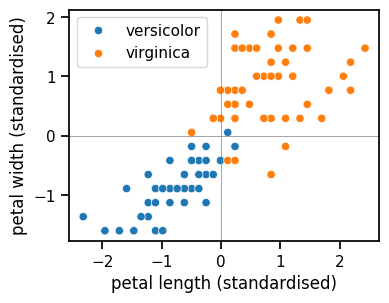

In [ ]:
# your code here

mask = (species != "setosa").values
cols = ["petal length (cm)", "petal width (cm)"]
df2 = df_iris.loc[mask, cols]
sp2 = species[mask]

xy = sklearn.preprocessing.StandardScaler().fit_transform(df2)
fig, ax = plt.subplots(figsize=(4, 4))
sns.scatterplot(x=xy[:, 0], y=xy[:, 1], hue=sp2.values, ax=ax)
ax.set(xlabel="petal length (standardised)", ylabel="petal width (standardised)", aspect="equal")
ax.axhline(0, c="grey", lw=0.5); ax.axvline(0, c="grey", lw=0.5)
plt.show()

## Task 3.2 – rotate
Write a function `rotate(xy, alpha_deg)` that applies the rotation matrix to an array of shape (n, 2).
Then make a composite figure (e.g. 2 × 4 panels) showing the rotated point cloud for angles between 0° and 180°.
In each panel draw the new $x'$ axis and print $\sum y_i'^2$ in the title.


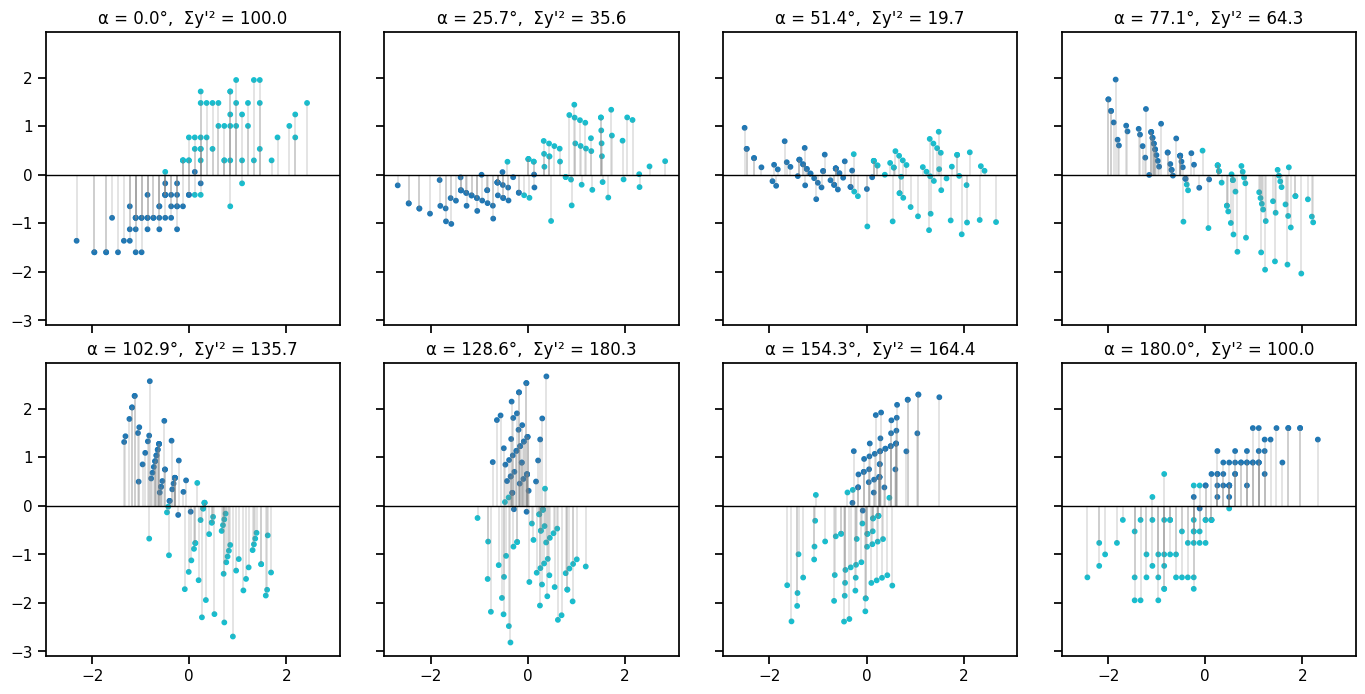

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def rotate(xy, alpha_deg):
  a = np.deg2rad(alpha_deg)
  R = np.array([[np.cos(a), np.sin(a)],
                [-np.sin(a), np.cos(a)]])
  return (R @ xy.T).T

angles = np.linspace(0, 180, 8)      # 0, 22.5, ..., 157.5
codes = pd.factorize(sp2)[0]         # 0/1 per species, only for colouring

fig, axes = plt.subplots(2, 4, figsize=(14, 7), sharex=True, sharey=True)
for ax, alpha in zip(axes.ravel(), angles):
    xr = rotate(xy, alpha)
    ax.scatter(xr[:, 0], xr[:, 1], c=codes, cmap="tab10", s=10)
    ax.vlines(xr[:, 0], 0, xr[:, 1], color="grey", lw=0.3)   # perpendicular residuals y'
    ax.axhline(0, c="k", lw=1)                               # the new x' axis
    ax.set(title=f"α = {alpha:.1f}°,  Σy'² = {np.sum(xr[:, 1]**2):.1f}", aspect="equal")
plt.tight_layout(); plt.show()

## Task 3.3 – the unexplained variance as a function of the angle
For $\alpha$ from 0° to 360° compute $\sum_i y_i'^2$ and plot it against the angle. A polar plot makes the symmetry visible:

```python
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
ax.plot(alpha_rad, r)
```

Also plot $\sum_i x_i'^2$ (the explained part). What is $\sum x'^2 + \sum y'^2$, and why is it constant?


min of sum y'^2 at 45 deg, value 17.67
max of sum x'^2 at 225 deg, value 182.33
sum x'^2 + sum y'^2: min 200.0 max 200.0 | sum of xy**2 = 200.0


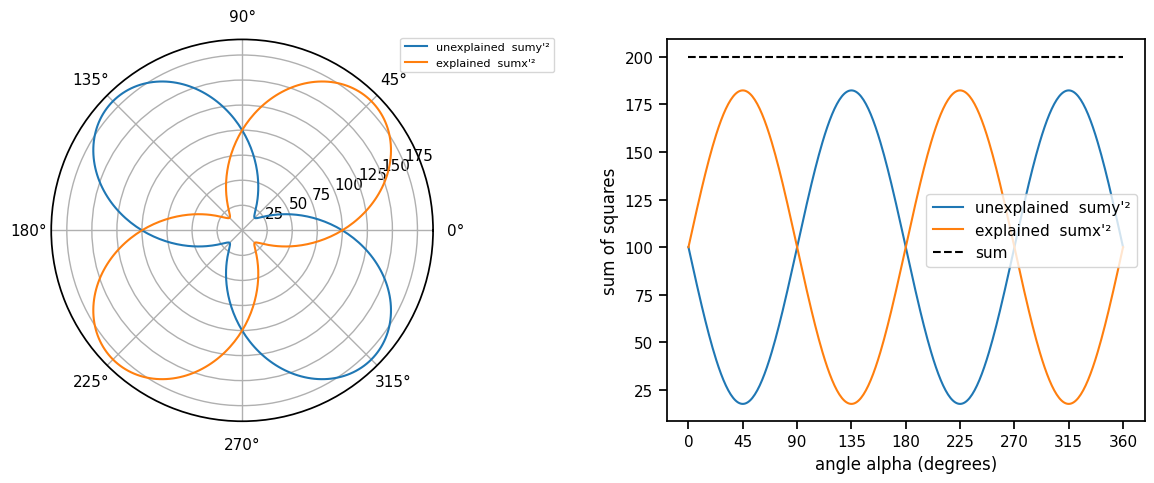

In [ ]:
# your code here

alphas = np.arange(0, 361, 1)                                # degrees
ss_y = np.array([np.sum(rotate(xy, a)[:, 1]**2) for a in alphas])   # unexplained sum of y'^2
ss_x = np.array([np.sum(rotate(xy, a)[:, 0]**2) for a in alphas])   # explained sum of x'^2

print("min of sum y'^2 at", alphas[np.argmin(ss_y)], "deg, value", ss_y.min().round(2))
print("max of sum x'^2 at", alphas[np.argmax(ss_x)], "deg, value", ss_x.max().round(2))
print("sum x'^2 + sum y'^2: min", (ss_x + ss_y).min().round(6), "max", (ss_x + ss_y).max().round(6),
      "| sum of xy**2 =", np.sum(xy**2).round(6))

alpha_rad = np.deg2rad(alphas)
fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(1, 2, 1, projection="polar")
ax1.plot(alpha_rad, ss_y, label="unexplained  sumy'²")
ax1.plot(alpha_rad, ss_x, label="explained  sumx'²")
ax1.legend(loc="lower left", bbox_to_anchor=(0.9, 0.9), fontsize=8)

ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(alphas, ss_y, label="unexplained  sumy'²")
ax2.plot(alphas, ss_x, label="explained  sumx'²")
ax2.plot(alphas, ss_x + ss_y, "k--", label="sum")
ax2.set(xlabel="angle alpha (degrees)", ylabel="sum of squares", xticks=range(0, 361, 45))
ax2.legend()
plt.tight_layout(); plt.show()

# Rotation does not change the length of a vector
#and hence sum x'^2 + sum y'^2 is constant under rotation


## Task 3.4 – compare with the SVD
Compute the SVD of the standardised 2-D data. The first right singular vector `Vt[0]` points along the first
principal component; its angle is `np.arctan2(Vt[0,1], Vt[0,0])`. Compare with the minimum you found.
Also compare $s_2^2$ with the minimum of the unexplained sum of squares, and $s_1^2$ with its maximum.


In [ ]:
# your code here

U2, S2, Vt2 = np.linalg.svd(xy, full_matrices=False)

angle_svd = np.rad2deg(np.arctan2(Vt2[0, 1], Vt2[0, 0])) % 180     # direction of PC1, folded into 0..180
angle_scan = alphas[np.argmin(ss_y)] % 180

print("Vt[0] =", Vt2[0].round(4))
print(f"PC1 angle from SVD: {angle_svd:.2f} deg,  minimum of sum y'^2 at {angle_scan} deg")
print(f"s2^2 = {S2[1]**2:.3f}  vs  min of sum y'^2 = {ss_y.min():.3f}")
print(f"s1^2 = {S2[0]**2:.3f}  vs  max of sum x'^2 = {ss_x.max():.3f}")
print(f"s1^2 + s2^2 = {np.sum(S2**2):.3f}  vs  sum of xy**2 = {np.sum(xy**2):.3f}")

Vt[0] = [0.7071 0.7071]
PC1 angle from SVD: 45.00 deg | minimum of sum y'^2 from scan: 45 deg
s2^2 = 17.665  vs  min of sum y'^2 = 17.665
s1^2 = 182.335  vs  max of sum x'^2 = 182.335
s1^2 + s2^2 = 200.000  vs  sum of xy**2 = 200.000


**Take-home.** PCA finds the rotation that makes the *perpendicular* residuals smallest. That is different from
linear regression, which minimises the *vertical* residuals ($y$ given $x$). Regression treats one variable as the
cause and the other as the effect; PCA treats them symmetrically. Because the two standardised variables here are
strongly correlated, PC1 sits at ≈ 45° – when all variables are standardised and equally correlated the first
component is simply their average.


# Part 4 – SVD on a spectro-kinetic dataset: what it can and cannot tell you

SVD is the workhorse for **time-resolved spectroscopy**: a transient-absorption matrix has time along one axis and
wavelength along the other, and SVD tells you how many independent spectral components are needed to describe it.
We construct such a dataset with **known** answers and try to retrieve them.

The model: a ground state GS is excited at $t=0$ and relaxes through three intermediates

$$\mathrm{GS} \xrightarrow{h\nu} \mathrm{A} \xrightarrow{k_1} \mathrm{B} \xrightarrow{k_2} \mathrm{C} \xrightarrow{k_3} \mathrm{GS}$$

with lifetimes 0.1 ps, 10 ps and 1000 ps. Every species has a Gaussian spectrum. The measured signal is the
**difference** absorbance, so the depleted ground state appears as a negative "bleach" with concentration
$c_\mathrm{GS}(t) = -(c_A + c_B + c_C)$. The data matrix is the sum of outer products

$$D(t,\lambda) = \sum_{\text{species } j} c_j(t)\, \varepsilon_j(\lambda) \qquad\Longleftrightarrow\qquad D = C\,E^T$$

(with $C$: time × species, $E$: wavelength × species). This is exactly the form SVD decomposes – so it should work perfectly, right?

The concentrations for a sequential first-order scheme have an analytic solution (the *Bateman* equations), which we use
instead of a hand-written Euler loop; that keeps the example exact and fast.


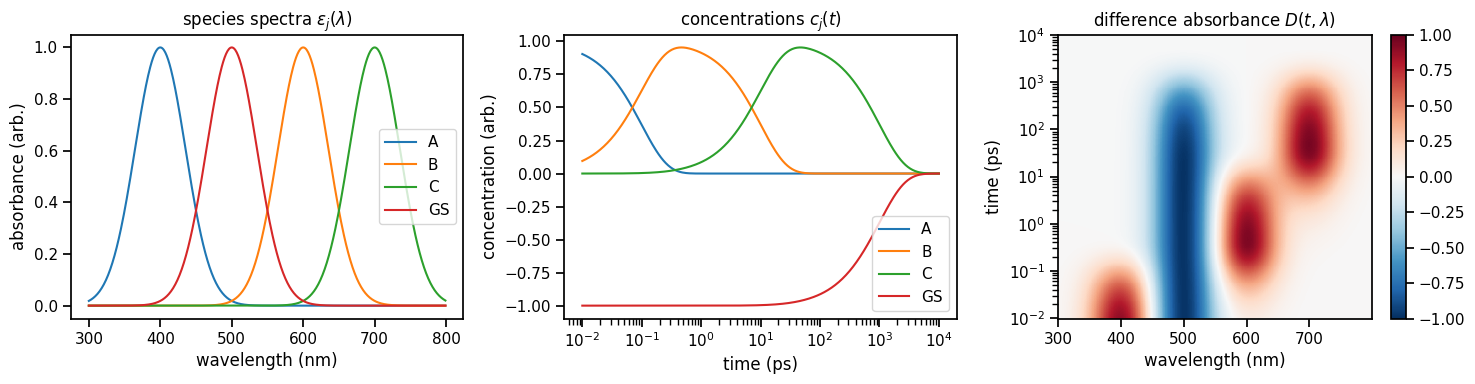

data shape (time x wavelength): (300, 500)


In [ ]:
def sequential_kinetics(t, k1, k2, k3):
    '''Concentrations of A, B, C for A -> B -> C -> (GS) with A(0)=1 (Bateman equations).'''
    A = np.exp(-k1 * t)
    B = k1 / (k2 - k1) * (np.exp(-k1 * t) - np.exp(-k2 * t))
    C = k1 * k2 * (np.exp(-k1 * t) / ((k2 - k1) * (k3 - k1))
                   + np.exp(-k2 * t) / ((k1 - k2) * (k3 - k2))
                   + np.exp(-k3 * t) / ((k1 - k3) * (k2 - k3)))
    return np.column_stack([A, B, C])

gauss = lambda x, mu, sigma=50: np.exp(-((x - mu) / sigma) ** 2)

wavelength = np.arange(300, 800, 1.0)                       # nm
time = np.logspace(-2, 4, 300)                               # ps, log spaced
lifetimes = np.array([0.1, 10.0, 1000.0])                    # ps
rates = 1 / lifetimes

spectra = pd.DataFrame({"A": gauss(wavelength, 400), "B": gauss(wavelength, 600),
                        "C": gauss(wavelength, 700), "GS": gauss(wavelength, 500)}, index=wavelength)
spectra.index.name = "wavelength (nm)"

conc = pd.DataFrame(sequential_kinetics(time, *rates), index=time, columns=["A", "B", "C"])
conc["GS"] = -conc.sum(axis=1)                               # the bleach: what left the ground state is missing there
conc.index.name = "time (ps)"

data = pd.DataFrame(conc.values @ spectra.values.T, index=conc.index, columns=spectra.index)   # D = C E^T, shape (time, wavelength)

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
spectra.plot(ax=ax[0], title="species spectra $\\varepsilon_j(\\lambda)$"); ax[0].set_ylabel("absorbance (arb.)")
conc.plot(ax=ax[1], logx=True, title="concentrations $c_j(t)$"); ax[1].set_ylabel("concentration (arb.)")
pm = ax[2].pcolormesh(data.columns, data.index, data.values, cmap="RdBu_r", vmin=-1, vmax=1, shading="auto")
ax[2].set(yscale="log", xlabel=spectra.index.name, ylabel=conc.index.name, title="difference absorbance $D(t,\\lambda)$")
fig.colorbar(pm, ax=ax[2]); plt.tight_layout(); plt.show()
print("data shape (time x wavelength):", data.shape)


## Task 4.1 – SVD of the data matrix
Apply `np.linalg.svd` to `data` (no centring here – why not?). Plot

* the singular values (a scree plot, log scale),
* the first three **left** singular vectors against time (these are "kinetics"),
* the first three **right** singular vectors against wavelength (these are "spectra"),
* and, in a separate panel, the fourth pair – what does a singular vector that belongs to a singular value of $10^{-13}$ look like?

Check the shapes against the DataFrame first so you know which is which.
**How many significant components are there? Why is that number different from the number of species?
Do the singular vectors look like the spectra and concentrations we put in? Why not?**


data (300, 500) | U (300, 300) S (300,) Vt (300, 500)
first 6 singular values: [1.33043888e+02 5.66909287e+01 4.03674759e+01 1.18166710e-13
 5.81007223e-14 5.78568868e-14]


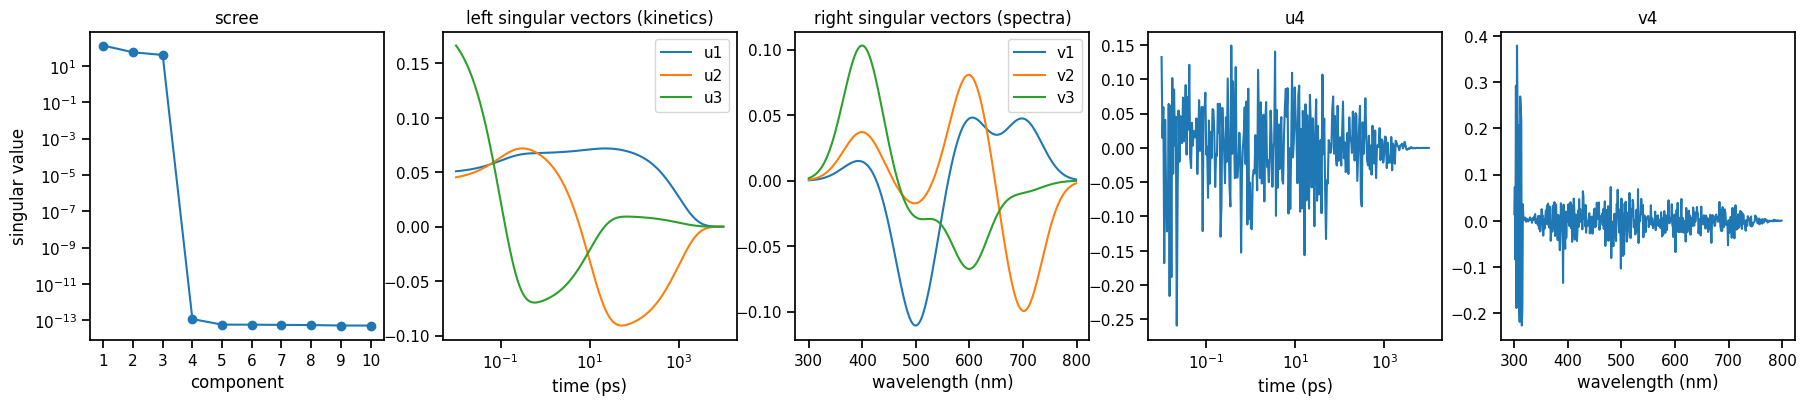

In [ ]:
# your code here

U, S, Vt = np.linalg.svd(data, full_matrices=False)
print("data", data.shape, "| U", U.shape, "S", S.shape, "Vt", Vt.shape)
print("first 6 singular values:", S[:6])

fig, ax = plt.subplots(1, 5, figsize=(22, 4))
ax[0].semilogy(range(1, 11), S[:10], "o-")
ax[0].set(xlabel="component", ylabel="singular value", title="scree", xticks=range(1, 11))
for j in range(3):
    ax[1].plot(time, U[:, j], label=f"u{j+1}")
    ax[2].plot(wavelength, Vt[j], label=f"v{j+1}")

ax[1].set(xscale="log", xlabel="time (ps)", title="left singular vectors (kinetics)")
ax[1].legend()
ax[2].set(xlabel="wavelength (nm)", title="right singular vectors (spectra)")
ax[2].legend()
ax[3].plot(time, U[:, 3]); ax[3].set(xscale="log", xlabel="time (ps)", title="u4")
ax[4].plot(wavelength, Vt[3]); ax[4].set(xlabel="wavelength (nm)", title="v4")
plt.show()


**Answer.** Only **three** singular values are non-zero, although we built the data from **four** species.
The reason is the mass balance $c_\mathrm{GS} = -(c_A+c_B+c_C)$: the concentration matrix has rank 3, so the data
matrix cannot have rank 4. SVD counts *linearly independent* components, not chemical species – a difference
spectroscopy experiment can never tell you more than $n_\text{species}-1$ from the rank alone.

The singular vectors are also **not** the spectra or kinetics we put in. Each $v_j$ is a mixture of several
Gaussians with positive and negative lobes, and the $u_j$ show unphysical sign changes. SVD returns an *orthonormal*
basis ordered by variance; real spectra are neither orthogonal nor ordered. Any invertible matrix $T$ gives an equally
valid factorisation $D = (CT)(T^{-1}E^T)$ – this is the **rotational ambiguity**. SVD alone therefore reduces
dimensions and denoises, but the *interpretation* needs additional information: a kinetic model, non-negativity,
known spectra … which is what "global analysis" (part 4.3) adds.


## Task 4.2 – low-rank approximation and noise
Add Gaussian noise (e.g. standard deviation 0.05) to `data`, repeat the SVD and look at the scree plot again.
Reconstruct the data from the first $k$ components only, $D_k = U_{:,:k}\,\mathrm{diag}(s_{:k})\,V^T_{:k}$, for $k = 1, 2, 3, 6$ and
plot the residual $D_\text{noisy} - D_k$ (as an image) and its standard deviation. What is the "right" $k$ and how do you see it?


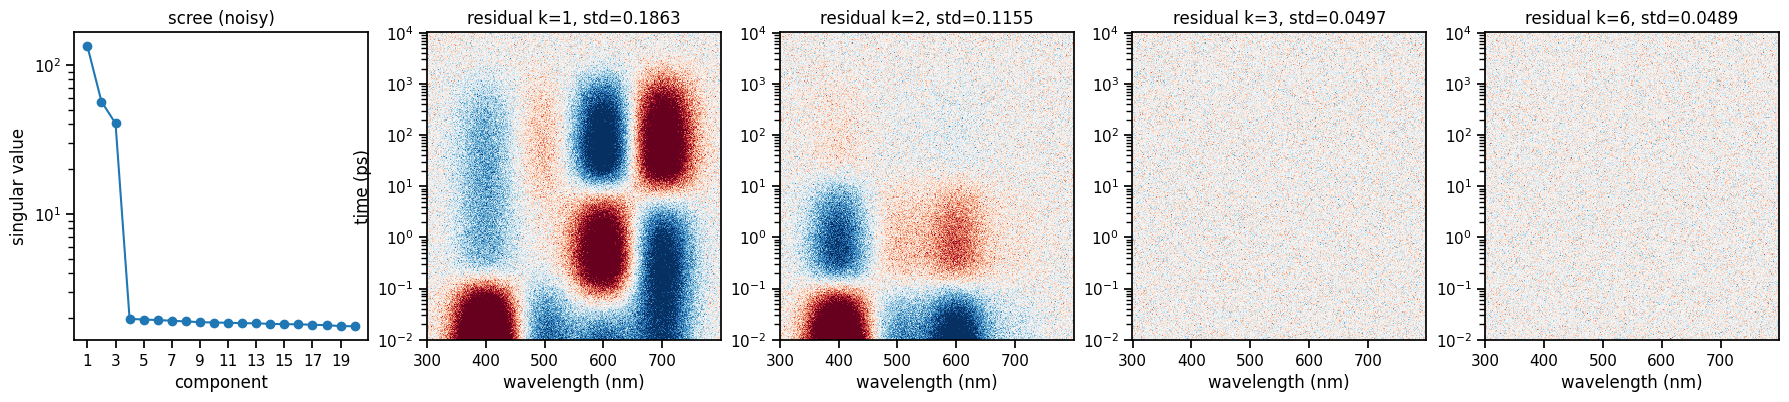

k=1: residual std = 0.1863
k=2: residual std = 0.1155
k=3: residual std = 0.0497
k=6: residual std = 0.0489


In [ ]:
# your code here


D_noisy = data.values + 0.05 * np.random.randn(*data.shape)

U, S, Vt = np.linalg.svd(D_noisy, full_matrices=False)

ks = [1, 2, 3, 6]

fig, ax = plt.subplots(1, 5, figsize=(22, 4))
ax[0].semilogy(range(1, 21), S[:20], "o-")
ax[0].set(xlabel="component", ylabel="singular value", title="scree (noisy)", xticks=range(1, 21, 2))

def reconstruct(k):
    return (U[:, :k] * S[:k]) @ Vt[:k]          # D_k = U_k diag(s_k) V_k^T

for a, k in zip(ax[1:], ks):
    R = D_noisy - reconstruct(k)
    a.pcolormesh(wavelength, time, R, cmap="RdBu_r", vmin=-0.3, vmax=0.3, shading="auto")
    a.set(yscale="log", xlabel="wavelength (nm)", title=f"residual k={k}, std={R.std():.4f}")

ax[1].set_ylabel("time (ps)")
plt.show()

for k in ks:
    print(f"k={k}: residual std = {(D_noisy - reconstruct(k)).std():.4f}")

**Answer.** With noise, the scree plot shows three singular values standing clearly above a flat "noise floor";
the floor is where the singular values of pure noise sit. With $k=1$ and $k=2$ the residual still contains
structure (you can see the missing species); at $k=3$ the residual is featureless and its standard deviation equals
the noise we added (0.05). Adding more components only fits noise – $k=6$ lowers the residual a little, but by
modelling noise, not chemistry. The truncated SVD $D_3$ is a **denoised** version of the data; this is the
"low-rank approximation" from the lecture.


In [ ]:
D3 = reconstruct(3)
print("noisy vs clean  :", (D_noisy - data.values).std())
print("denoised vs clean:", (D3 - data.values).std())

noisy vs clean  : 0.050052444265338274
denoised vs clean: 0.006228135352599424


## Task 4.3 – from SVD to global analysis
SVD told us *how many* components there are. To get physically meaningful spectra we add a **model**: we know (or
guess) that the kinetics are sequential with three lifetimes. Then for a given set of lifetimes the concentration
matrix $C(t)$ is fixed and the spectra follow from a linear least-squares problem

$$E^T = \arg\min_E \| D - C E^T \|^2 \quad\Rightarrow\quad E^T = C^{+} D$$

(`np.linalg.lstsq(C, D)`). The lifetimes themselves are then found by non-linear least squares on the residual
(`scipy.optimize.least_squares`) – this is what packages such as *Glotaran* or *KiMoPack* do.

One subtlety follows directly from the rank argument above: because $c_\mathrm{GS} = -(c_A+c_B+c_C)$, the four-column
concentration matrix is singular, and `lstsq` would return an arbitrary (minimum-norm) split between species and bleach.
So we fit with the **three** independent columns $c_A, c_B, c_C$ only. The spectra we then obtain are the
**species-associated difference spectra** $\Delta\varepsilon_j = \varepsilon_j - \varepsilon_\mathrm{GS}$
– every species is seen relative to the ground state it came from. This is the standard result of a transient-absorption analysis.

* Write a function `residual(log_tau)` that builds $C$ (three columns) for the three lifetimes (in log scale so they stay
  positive), solves for $E$ by `lstsq`, and returns the flattened residual $D_\text{noisy} - CE^T$.
* Start from deliberately wrong guesses (e.g. lifetimes 0.3, 30, 300 ps), run `least_squares`, and compare the
  fitted lifetimes and difference spectra with the truth ($\varepsilon_j - \varepsilon_\mathrm{GS}$).


In [ ]:
# your code here


**Take-home for the spectroscopist.** SVD is the model-free first look: it tells you the rank (how many
components) and denoises. It does *not* give you species spectra, because of the rotational ambiguity and because
the bleach couples the species. Even with a model, the linear dependence between bleach and species survives:
you get *difference* spectra, and recovering the absolute $\varepsilon_j$ needs one more piece of information (the
ground-state spectrum, measured separately). Global analysis breaks the ambiguity by imposing a kinetic model – then the linear
part (spectra) is solved exactly by least squares and only the few non-linear parameters (lifetimes) need iteration.
The same structure – linear parameters solved by `lstsq`, non-linear ones by an optimiser – is called *variable
projection* and is used far beyond spectroscopy.


# Part 5 – Clustering with k-means

We return to the iris data. **k-means** minimises the within-cluster sum of squares

$$J = \sum_{i=1}^{k}\sum_{x\in C_i}\|x-\mu_i\|^2$$

by alternating between assigning each point to the nearest centroid and moving each centroid to the mean of its
points. It always converges, but only to a *local* minimum – the result depends on the random start.
scikit-learn therefore runs it `n_init` times and keeps the best.

## Task 5.1 – k and the random start
Use the code skeleton below (5 × 5 panels; the first row shows the true species in the petal-length/petal-width
plane). Fill rows 2–5 with `sklearn.cluster.KMeans` results on **all four** columns: across the columns use
`n_clusters` = 1 … 5, across the rows use `n_init` = 1, 2, 5, 20 (with `random_state=2`, or vary it).
Look closely: where and when do the results differ?
Then repeat with only two columns (e.g. sepal length and sepal width) as input and describe the difference.


In [ ]:
def kmeans_grid(X, title):
    '''5x5 grid: true labels in row 0, k-means with k=1..5 (columns) and n_init=1,2,5,20 (rows 1..4).'''
    fig, ax = plt.subplots(5, 5, figsize=(12, 12), sharex=True, sharey=True)
    for sp in iris.target_names:                                     # row 0: the truth (for our eyes only)
        m = (species == sp).values
        for j in range(5):
            ax[0, j].scatter(df_iris.iloc[m, 2], df_iris.iloc[m, 3], s=4, label=sp)
    ax[0, 0].legend(fontsize=7, markerscale=3); ax[0, 0].set_ylabel("true species")
    # --- rows 1..4 are filled in Task 5.1 ---
    return fig, ax

fig, ax = kmeans_grid(df_iris.values, "all four columns")
plt.close(fig)        # only a skeleton; the real figure is produced below


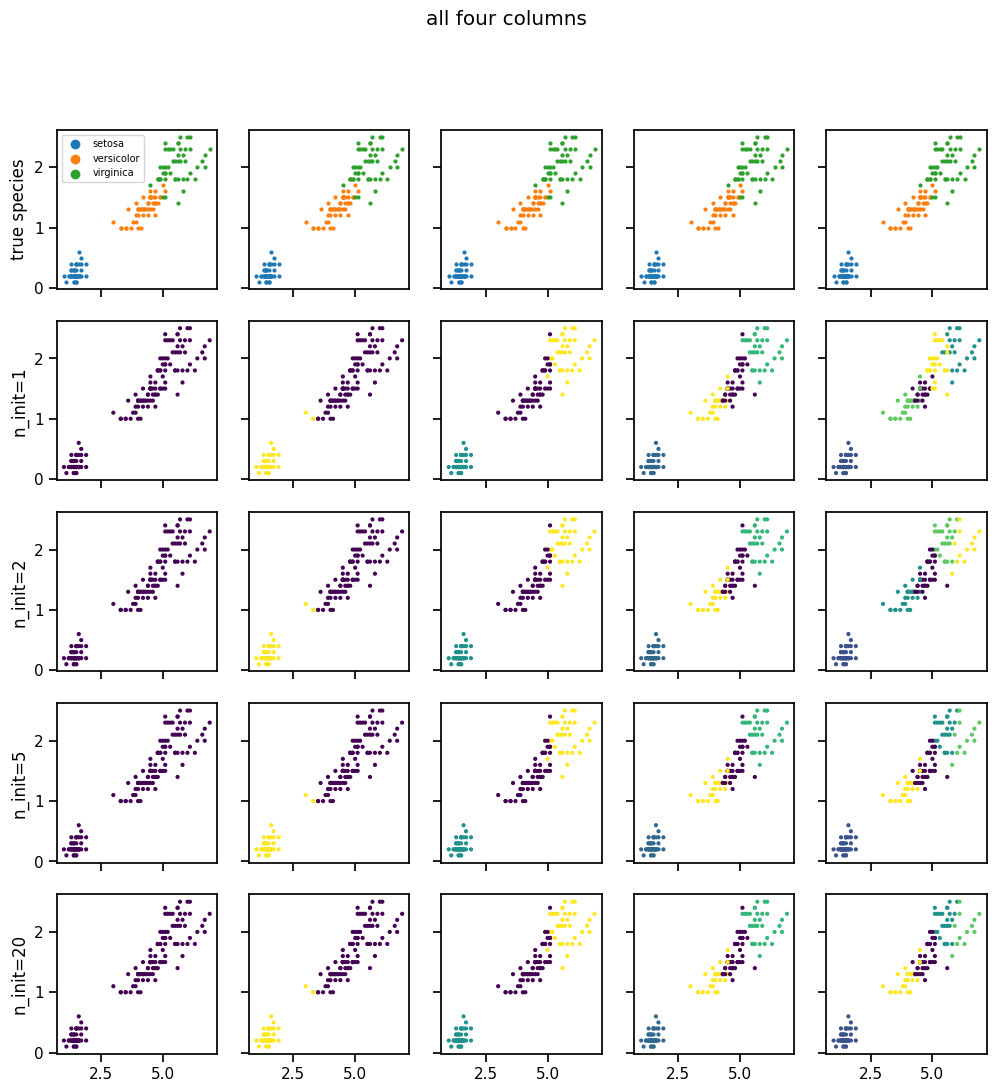

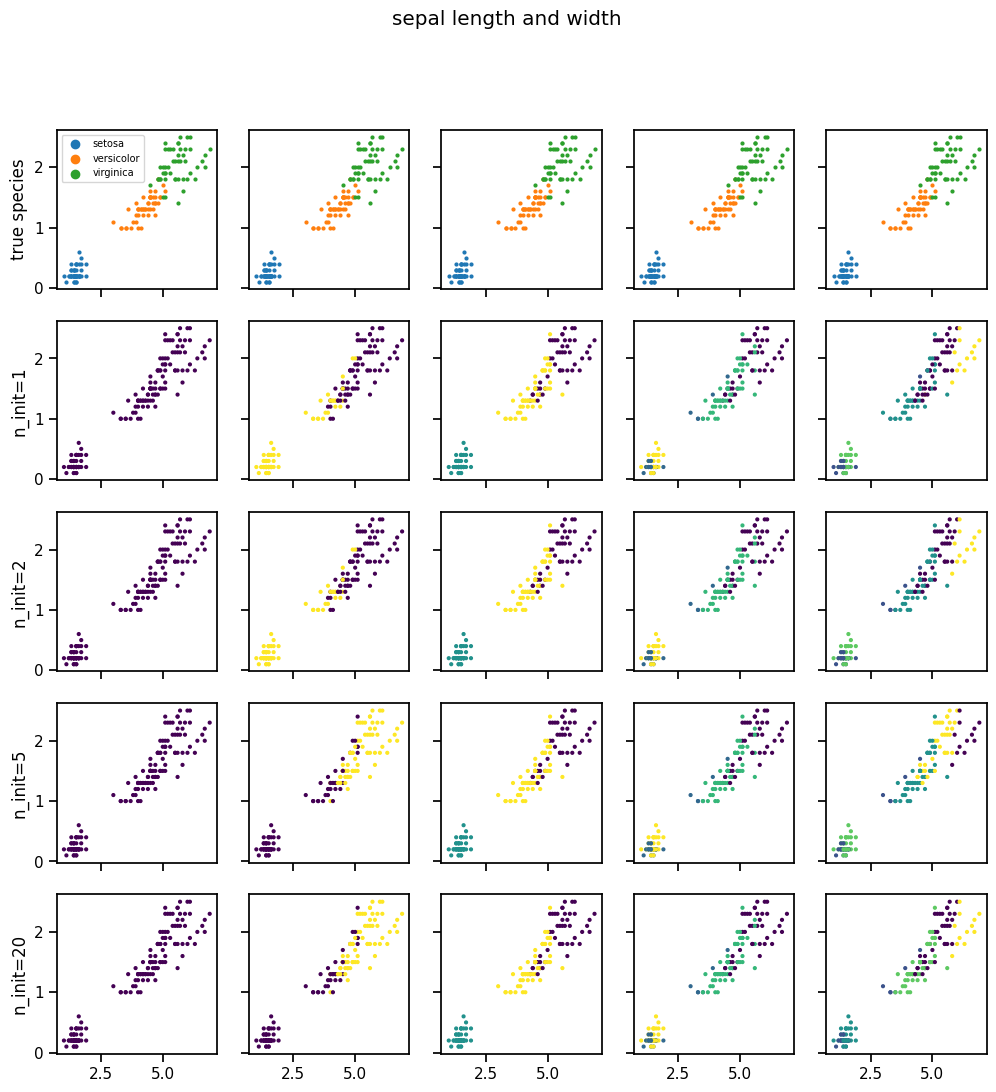

In [ ]:
# your code here

def kmeans_grid(X, title):
    fig, ax = plt.subplots(5, 5, figsize=(12, 12), sharex=True, sharey=True)
    for sp in iris.target_names:
        m = (species == sp).values
        for j in range(5):
            ax[0, j].scatter(df_iris.iloc[m, 2], df_iris.iloc[m, 3], s=4, label=sp)
    ax[0, 0].legend(fontsize=7, markerscale=3); ax[0, 0].set_ylabel("true species")

    for i, n_init in enumerate([1, 2, 5, 20]):
        for k in range(1, 6):
            km = sklearn.cluster.KMeans(n_clusters=k, n_init=n_init, random_state=2).fit(X)
            ax[i + 1, k - 1].scatter(df_iris.iloc[:, 2], df_iris.iloc[:, 3], c=km.labels_, s=4)
        ax[i + 1, 0].set_ylabel(f"n_init={n_init}")
    fig.suptitle(title)
    return fig, ax

fig, ax = kmeans_grid(df_iris.values, "all four columns")
plt.show()
fig, ax = kmeans_grid(df_iris.iloc[:, :2].values, "sepal length and width")
plt.show()

**What to notice.** With k = 3 on all four columns k-means recovers *setosa* perfectly and mixes
*versicolor*/*virginica* only at their border. The inertia $J$ always falls when k rises – so $J$ alone cannot pick k.
With `n_init=1` and an unlucky seed the k = 4 or 5 solutions differ from run to run (compare the $J$ values):
that is the local-minimum problem. With only sepal length and width as input, the algorithm must draw its borders
in a plane where the species overlap, and the clusters no longer follow the species in the petal plane at all:
**clusters are only as good as the features you feed in.**


## Task 5.2 – how many clusters? Elbow and silhouette
Two standard criteria:

* **Elbow:** plot the inertia $J(k)$ for $k=1\dots10$ and look for the bend.
* **Silhouette:** for each point $i$, with $a_i$ the mean distance to the other points in its own cluster and $b_i$
  the mean distance to the points of the nearest *other* cluster,
  $$s_i = \frac{b_i - a_i}{\max(a_i, b_i)} \in [-1, 1].$$
  The mean silhouette over all points (`sklearn.metrics.silhouette_score`) is large when clusters are compact and
  well separated; scan $k = 2\dots10$ and pick the maximum (or the smallest $k$ on a plateau).

Compute both for the **standardised** iris data and for the raw data. Do they agree with the three species?
Also compute the `adjusted_rand_score` between the k = 3 labels and the true species (a chance-corrected agreement
score, 1 = perfect) – for us the only "ground truth" check we have.


raw ARI (k=3 vs species): 0.7302382722834697
standardised ARI (k=3 vs species): 0.6201351808870379


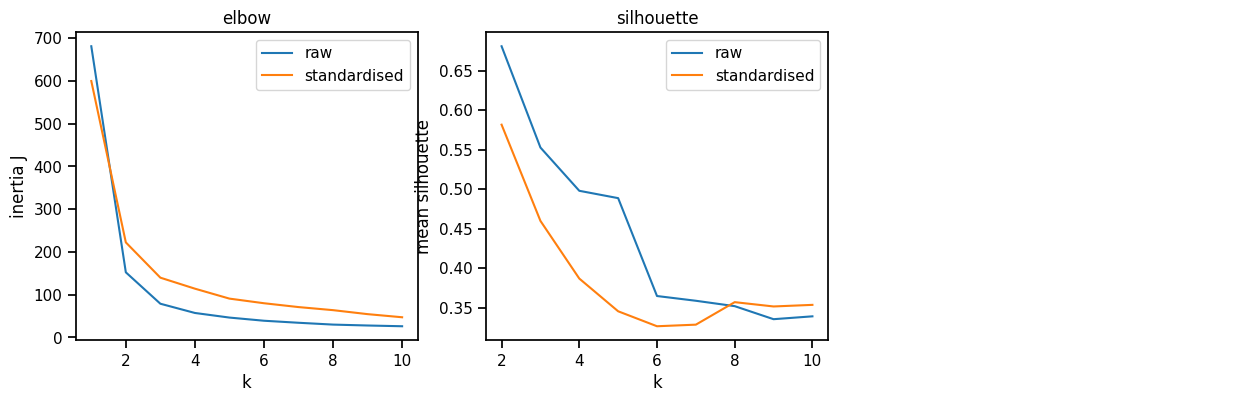

In [ ]:
# your code here

X_raw = df_iris.values
X_std = sklearn.preprocessing.StandardScaler().fit_transform(X_raw)

ks = range(2, 11)
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

for name, X in [("raw", X_raw), ("standardised", X_std)]:
    inertia = [sklearn.cluster.KMeans(n_clusters=k, n_init=20, random_state=2).fit(X).inertia_
               for k in range(1, 11)]
    sil = [sklearn.metrics.silhouette_score(X, sklearn.cluster.KMeans(n_clusters=k, n_init=20, random_state=2).fit_predict(X))
           for k in ks]
    ax[0].plot(range(1, 11), inertia, label=name)
    ax[1].plot(ks, sil, label=name)

    labels3 = sklearn.cluster.KMeans(n_clusters=3, n_init=20, random_state=2).fit_predict(X)
    print(name, "ARI (k=3 vs species):", sklearn.metrics.adjusted_rand_score(species, labels3))

ax[0].set(xlabel="k", ylabel="inertia J", title="elbow")
ax[1].set(xlabel="k", ylabel="mean silhouette", title="silhouette")
ax[0].legend(); ax[1].legend()
ax[2].axis("off")
plt.show()


**Discussion.** Both criteria prefer **k = 2**: *setosa* is far away from the other two species, which overlap.
Three is defensible as a second choice, especially in the raw data. This is the honest answer of unsupervised
learning: the data contain two clearly separated groups, and the split of the second group into two species is
information that only the labels carry. Note that k-means on the raw data actually agrees *better* with the species
(higher ARI) than on standardised data, because scaling inflates the noisy sepal width. Scaling is not automatically better.

A silhouette **plot** (per-point silhouettes sorted within each cluster, `sklearn.metrics.silhouette_samples`) shows
*which* cluster is weak; the mean alone hides this.


# Part 6 – Hierarchical clustering

Agglomerative clustering starts with every point as its own cluster and merges the two closest clusters until one
remains. The whole history of merges is the **dendrogram**; cutting it at a height gives a partition. "Closest"
depends on the **linkage**:

| linkage | distance between clusters | tends to give |
|---|---|---|
| single | min over all pairs | long chains, sensitive to noise bridges |
| complete | max over all pairs | compact, similar-sized clusters |
| average | mean over all pairs | in between |
| Ward | increase of within-cluster variance on merging | compact, like k-means |

## Task 6.1 – dendrograms
Use `scipy.cluster.hierarchy.linkage` on the standardised iris data with the four linkage methods and draw the four
dendrograms (`scipy.cluster.hierarchy.dendrogram`, colour the leaves by the true species with `link_color_func` or
simply compare the leaf order). Where would you cut each tree? Then cut at three clusters (`fcluster(..., 3, 'maxclust')`,
or `sklearn.cluster.AgglomerativeClustering`) and compute the adjusted Rand index against the species.


In [ ]:
# your code here


**Discussion.** Ward and complete linkage give the "textbook" trees with one big early split (setosa vs. the rest)
and a defensible second split. Single linkage chains the overlapping *versicolor*/*virginica* points into one
cluster and peels off outliers one by one – the classic failure mode of single linkage on data without gaps.
The dendrogram's vertical axis answers the question "how many clusters?" visually: a long vertical stretch without
merges means the clusters below it are well separated. Cutting there is the hierarchical equivalent of the elbow.


# Part 7 – Choosing the right clustering method: the smileys

The folder with the smiley images contains point clouds: a clean set (`cl_*`) and a noisy set (`bl_*`). Every dark
pixel is one observation with two features, its $x$ and $y$ position. The task is to recover the "domains"
(eyes, mouth, ring). This mimics a very common problem in microscopy – e.g. the magnetic domains in the NdFeB
micrograph in the same folder (Gorchy, CC BY-SA 3.0, [Wikimedia Commons](https://commons.wikimedia.org/w/index.php?curid=4459327)).

We first turn an image into a point cloud with scikit-image (no OpenCV needed).


['bl_1_o.png', 'bl_2_o.png', 'bl_3_o.png', 'bl_4_o.png', 'cl_1_o.png', 'cl_2_o.png', 'cl_3_o.png', 'cl_4_o.png']


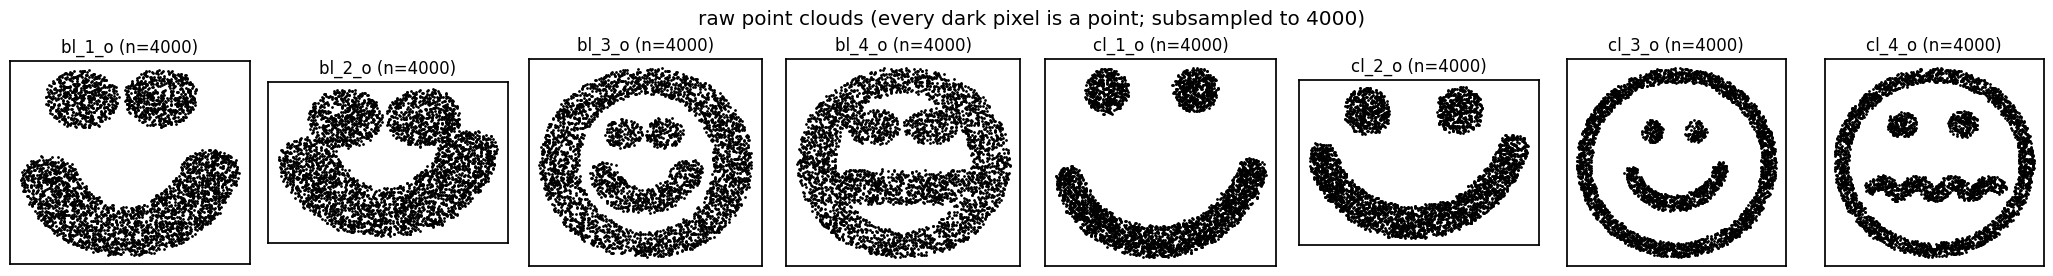

In [ ]:
import skimage.transform
from sklearn.neighbors import NearestNeighbors

def image_to_points(path, threshold=0.5, binning="auto", max_points=4000, rng=None, target_width=160):
    # Turn an image into a point cloud: every dark pixel becomes one observation (x, y).
    # binning > 1 first averages blocks of binning x binning pixels (skimage.transform.downscale_local_mean),
    # which raises the signal-to-noise ratio of a dotted image before thresholding. binning="auto" picks the
    # bin size that brings every image to about target_width pixels, so all images get a comparable point density.
    # Coordinates are divided by the image width, so all images live in the same unit square and
    # a distance parameter such as DBSCAN eps has the same meaning for every image.
    rng = rng or np.random.default_rng(RNG_SEED)
    img = skimage.io.imread(path)
    if img.ndim == 3 and img.shape[2] == 4:                     # RGBA: put transparent pixels on white
        alpha = img[..., 3:4] / 255.0
        img = (img[..., :3] * alpha + 255 * (1 - alpha)).astype(np.uint8)
    gray = skimage.color.rgb2gray(img) if img.ndim == 3 else img / 255.0
    if binning == "auto":
        binning = max(1, round(gray.shape[1] / target_width))
    if binning > 1:
        h, w = (np.array(gray.shape) // binning) * binning     # crop to a multiple of the bin size (avoids edge artefacts)
        gray = skimage.transform.downscale_local_mean(gray[:h, :w], (binning, binning))
    ys, xs = np.nonzero(gray < threshold)                        # dark pixels are our observations
    pts = np.column_stack([xs, -ys]).astype(float) / gray.shape[1]   # flip y so the smiley is upright; scale to width 1
    if len(pts) > max_points:                                    # subsample for speed (spectral clustering is O(n^2))
        pts = pts[rng.choice(len(pts), max_points, replace=False)]
    return pts

def typical_spacing(pts):
    # median distance from a point to its nearest neighbour - a natural length scale for eps
    d, _ = NearestNeighbors(n_neighbors=2).fit(pts).kneighbors(pts)
    return np.median(d[:, 1])

def plot_clusters(ax, pts, labels, title):
    noise = labels == -1
    ax.scatter(pts[~noise, 0], pts[~noise, 1], c=labels[~noise], cmap="tab10", s=3)
    if noise.any(): ax.scatter(pts[noise, 0], pts[noise, 1], c="lightgrey", s=3)
    ax.set(title=title, aspect="equal", xticks=[], yticks=[])

def n_clusters(labels):
    return len(set(labels)) - (1 if -1 in labels else 0)

smiley_files = sorted(SMILEY_DIR.glob("*.png")) if SMILEY_DIR else []
clean = [f for f in smiley_files if f.stem.startswith("cl")]
noisy = [f for f in smiley_files if f.stem.startswith("bl")]
print([f.name for f in smiley_files])

fig, ax = plt.subplots(1, len(smiley_files), figsize=(2.6 * len(smiley_files), 2.8))
for a, f in zip(np.atleast_1d(ax), smiley_files):
    pts = image_to_points(f, binning=1)
    a.scatter(pts[:, 0], pts[:, 1], s=1, c="k"); a.set(title=f"{f.stem} (n={len(pts)})", aspect="equal", xticks=[], yticks=[])
fig.suptitle("raw point clouds (every dark pixel is a point; subsampled to 4000)"); plt.tight_layout(); plt.show()


## Task 7.1 – k-means vs DBSCAN vs spectral clustering
For each **clean** smiley (use the default `binning="auto"`, which brings every image to about 160 pixels width so that the
clouds are dense, uniform and quick to handle) cluster the point cloud with

* `sklearn.cluster.KMeans` (choose k = number of domains you see),
* `sklearn.cluster.DBSCAN` – a density-based method: a point is a *core point* if at least `min_samples` points lie
  within distance `eps`; connected core points form a cluster; the rest is noise (label −1). It needs no k, but it
  needs `eps`. A good starting point is a few times the typical nearest-neighbour spacing (`typical_spacing`).
* `sklearn.cluster.SpectralClustering` (with `affinity='nearest_neighbors'`) – builds a neighbourhood graph and
  clusters its eigenvectors; it can follow curved shapes.
* `sklearn.cluster.AgglomerativeClustering(linkage='single')` – single linkage should also follow connected shapes.

Show the results side by side. Which methods separate the ring from the face? Why does k-means fail there?


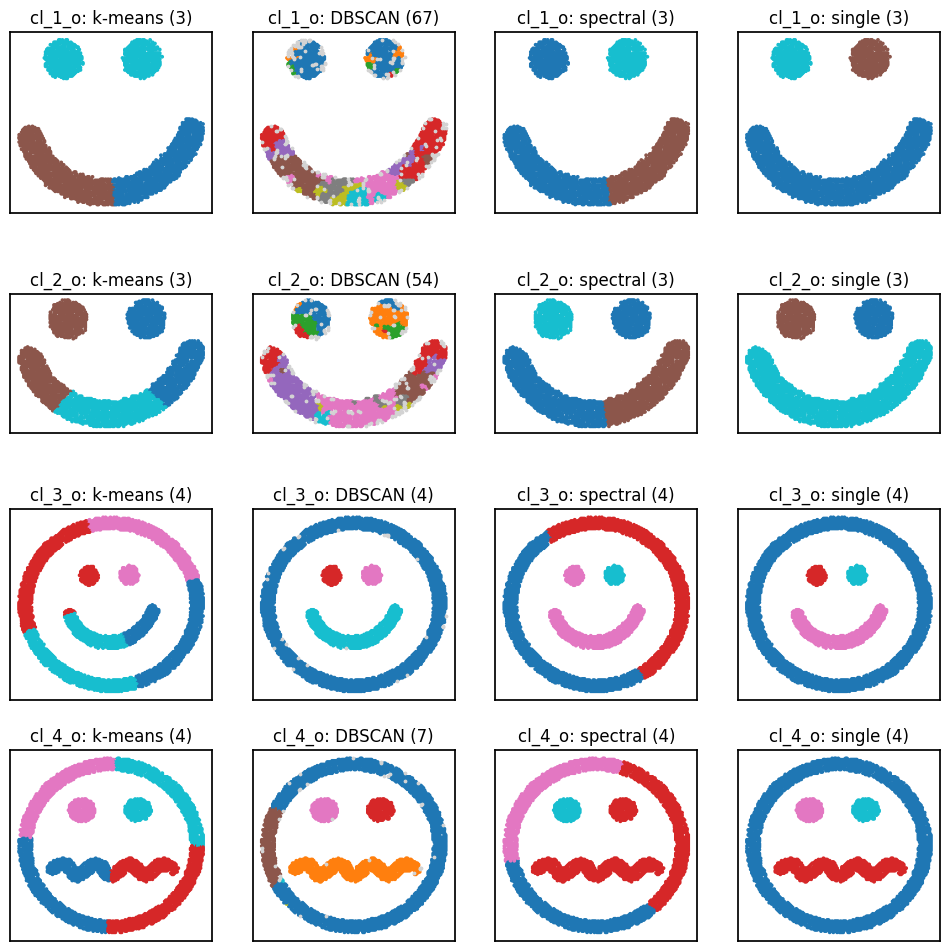

In [ ]:
# your code here

ks = [3, 3, 4, 4]

fig, ax = plt.subplots(4, 4, figsize=(12, 12))
for row, (f, k) in enumerate(zip(clean, ks)):
    pts = image_to_points(f)
    eps = 2 * typical_spacing(pts)

    results = {
        "k-means":  sklearn.cluster.KMeans(n_clusters=k, n_init=10, random_state=2).fit_predict(pts),

        "DBSCAN":   sklearn.cluster.DBSCAN(eps=eps).fit_predict(pts),

        "spectral": sklearn.cluster.SpectralClustering(n_clusters=k, affinity="nearest_neighbors", random_state=2).fit_predict(pts),

        "single":   sklearn.cluster.AgglomerativeClustering(n_clusters=k, linkage="single").fit_predict(pts)}


    for col, (name, labels) in enumerate(results.items()):
        plot_clusters(ax[row, col], pts, labels, f"{f.stem}: {name} ({n_clusters(labels)})")

plt.show()

**Discussion.** k-means partitions the plane into convex (Voronoi) cells, so it cuts the ring into pieces and
glues ring fragments to the nearest eye – it *cannot* represent a cluster that surrounds another one. DBSCAN and
single linkage follow connectivity and find eyes, mouth and ring as separate objects whenever there is a gap between
them; spectral clustering does too, because it works on the neighbourhood graph rather than on centroids.
The price: DBSCAN needs a sensible `eps` and treats isolated points as noise; spectral clustering still needs k and
is $O(n^2)$ in memory, which is why we subsampled; single linkage breaks as soon as a few stray points bridge two domains.


## Task 7.2 – the noisy smileys
Repeat for the noisy images `bl_*`. Two things now matter:

1. **DBSCAN's parameters.** On the raw point cloud (`binning=1`) scan `eps` over a few multiples of the typical spacing
   and watch the ring, the number of clusters and the fraction of points labelled noise.
2. **Pre-processing.** The background dots are sparse and the domains are dense. Averaging blocks of pixels
   (`binning="auto"`, i.e. 6–10 pixels for these images) before thresholding turns "sparse dots" into light grey and
   "dense dots" into dark grey – it raises the signal-to-noise ratio, exactly like binning a detector image.
   Cluster the binned cloud with DBSCAN and with k-means and compare.

Report the number of clusters and the noise fraction for each setting. Which combination recovers the domains?


bl_1_o raw, eps = 1 x spacing: 16 clusters
bl_1_o raw, eps = 2 x spacing: 225 clusters
bl_1_o raw, eps = 3 x spacing: 98 clusters
bl_1_o raw, eps = 4 x spacing: 3 clusters
bl_1_o raw, eps = 5 x spacing: 3 clusters
----------------------------------------
bl_2_o raw, eps = 1 x spacing: 16 clusters
bl_2_o raw, eps = 2 x spacing: 200 clusters
bl_2_o raw, eps = 3 x spacing: 92 clusters
bl_2_o raw, eps = 4 x spacing: 1 clusters
bl_2_o raw, eps = 5 x spacing: 1 clusters
----------------------------------------
bl_3_o raw, eps = 1 x spacing: 11 clusters
bl_3_o raw, eps = 2 x spacing: 260 clusters
bl_3_o raw, eps = 3 x spacing: 36 clusters
bl_3_o raw, eps = 4 x spacing: 3 clusters
bl_3_o raw, eps = 5 x spacing: 3 clusters
----------------------------------------
bl_4_o raw, eps = 1 x spacing: 10 clusters
bl_4_o raw, eps = 2 x spacing: 252 clusters
bl_4_o raw, eps = 3 x spacing: 18 clusters
bl_4_o raw, eps = 4 x spacing: 1 clusters
bl_4_o raw, eps = 5 x spacing: 1 clusters
---------------------

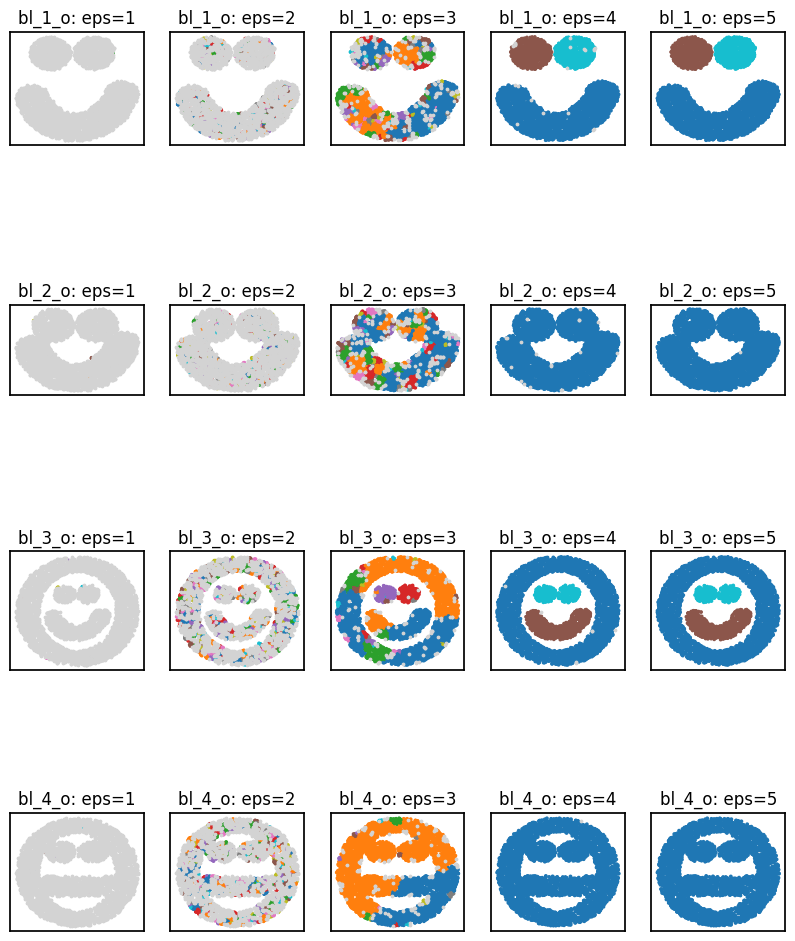

In [ ]:
# your code here

ks = [3, 3, 4, 4]

# 1) DBSCAN, scanning eps
factors = [1, 2, 3, 4, 5]

fig, ax = plt.subplots(4, 5, figsize=(10, 13))

for row, f in enumerate(noisy):
    pts = image_to_points(f, binning=1)
    spacing = typical_spacing(pts)

    for col, fac in enumerate(factors):
        labels = sklearn.cluster.DBSCAN(eps=fac * spacing).fit_predict(pts)
        print(f"{f.stem} raw, eps = {fac} x spacing: {n_clusters(labels)} clusters")
        plot_clusters(ax[row, col], pts, labels, f"{f.stem}: eps={fac}")
    print('-'*40)

plt.show()


bl_1_o binned: DBSCAN 9 clusters, k-means k=3
bl_2_o binned: DBSCAN 3 clusters, k-means k=3
bl_3_o binned: DBSCAN 166 clusters, k-means k=4
bl_4_o binned: DBSCAN 215 clusters, k-means k=4


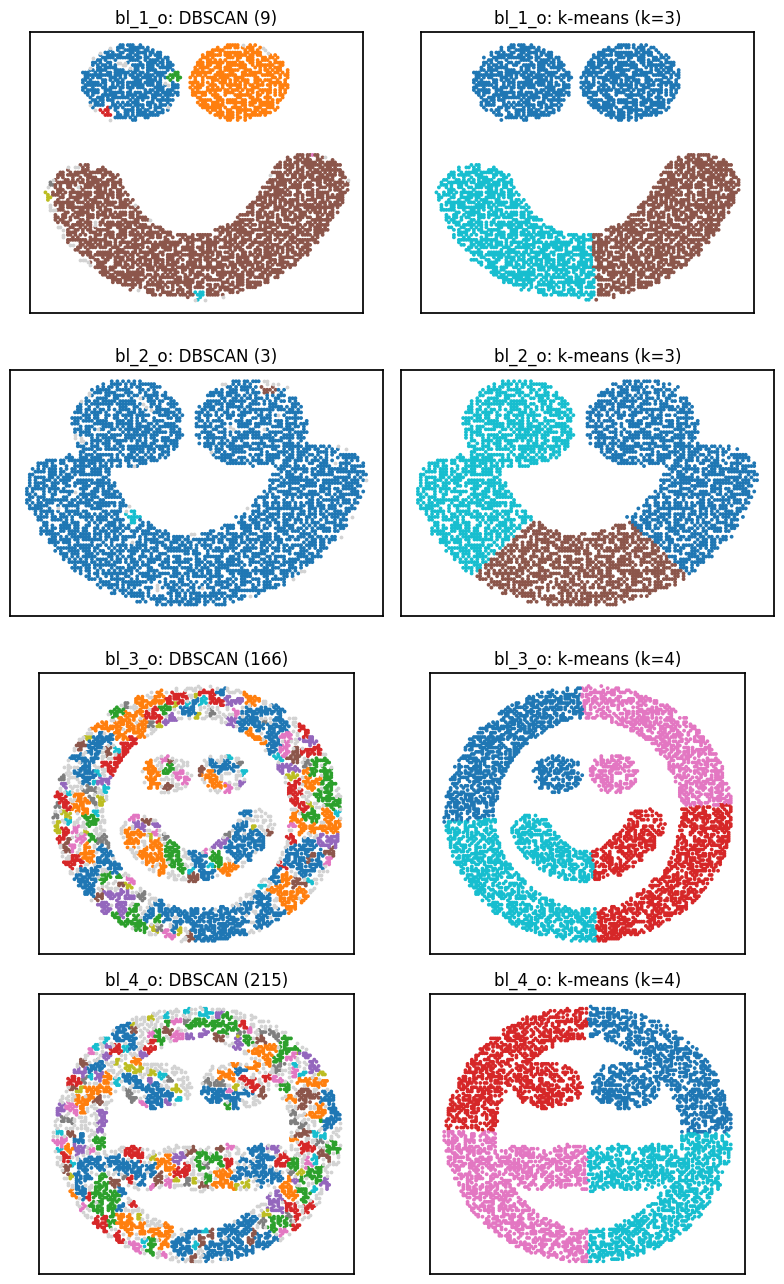

In [ ]:
# 2) binned point clouds: DBSCAN and k-means

fig, ax = plt.subplots(4, 2, figsize=(8, 13))

for row, (f, k) in enumerate(zip(noisy, ks)):
    pts = image_to_points(f)
    eps = 2 * typical_spacing(pts)

    lab_db = sklearn.cluster.DBSCAN(eps=eps).fit_predict(pts)
    lab_km = sklearn.cluster.KMeans(n_clusters=k, n_init=10, random_state=2).fit_predict(pts)

    print(f"{f.stem} binned: DBSCAN {n_clusters(lab_db)} clusters, k-means k={k}")
    plot_clusters(ax[row, 0], pts, lab_db, f"{f.stem}: DBSCAN ({n_clusters(lab_db)})")
    plot_clusters(ax[row, 1], pts, lab_km, f"{f.stem}: k-means (k={k})")
plt.tight_layout(); plt.show()

**Discussion.** On the raw noisy clouds DBSCAN has no *clean* setting: at 1.5 × spacing everything is noise, at
3 × the domains shatter into hundreds of fragments, and at 6 × the domains are found but nothing is rejected any more
(noise 0 %) – the sparse background dots are simply glued to the nearest domain. The density contrast between domain
and background is weak *at the pixel level*. After binning, the sparse background averages to light grey and vanishes
at the threshold while the dense domains survive; DBSCAN then finds eyes, mouth and ring in `bl_1` and `bl_3`
essentially perfectly. In `bl_2` and `bl_4` the domains *touch* (the eyes grow into the mouth, the grimace lines reach
the ring), so every connectivity-based method must return one cluster – there is no gap to find. Only a method with a
shape prior (k-means: convex blobs) can split them, and then it splits along the wrong lines because the shapes are not
convex. The lesson generalises: **pre-processing (binning, smoothing, the choice of features) often decides more than
the clustering algorithm**, and no algorithm can find a boundary that is not in the data. In a real experiment you
would fix the bin size from the resolution you need (what is the smallest domain I care about?) rather than by eye.

**Optional (image segmentation instead of point clouds).** For a grey-scale micrograph such as `NdFeB-Domains.jpg`
the observations are *pixels* and the feature is the *intensity* (plus, if you like, the position or a local texture
measure such as `skimage.filters.sobel`). k-means on intensity alone is then simple thresholding into k levels –
try it, and then add the pixel coordinates as extra features and observe what happens.


In [ ]:
# your code here


# Part 8 (bonus) – Linear vs non-linear dimension reduction

PCA can only rotate and project. When the interesting structure lies on a curved manifold, neighbourhood-preserving
methods such as **t-SNE** (and UMAP) often show it better. We compare them on the 8 × 8 handwritten digits (64
features, 10 classes) – a dataset where PCA to 2-D shows blobs that overlap, while t-SNE shows ten islands.

t-SNE measures pairwise similarities in high dimension with Gaussians, in low dimension with a heavy-tailed
t-distribution, and moves the low-dimensional points by gradient descent until the two similarity distributions
agree (Kullback–Leibler divergence). Its `perplexity` parameter sets the effective number of neighbours.

## Task 8.1
Load `sklearn.datasets.load_digits()`, standardise, and plot the 2-D PCA scores next to a 2-D t-SNE embedding
(`sklearn.manifold.TSNE(perplexity=30, init='pca', random_state=...)`), coloured by digit.
Then vary the perplexity (5, 30, 100). Which quantities in a t-SNE map are meaningful (cluster membership) and
which are **not** (cluster sizes, distances between clusters, axis orientation)?


In [ ]:
# your code here


**Discussion.** PCA keeps the global geometry (distances mean something) but the two leading components hold only
about a fifth of the variance and the digits overlap. t-SNE separates the ten digits into islands at moderate
perplexity, but the map is **qualitative**: the size of an island, the distance between islands and the orientation of
the axes carry no information, and a different `random_state` gives a different picture. Use t-SNE/UMAP to *look*
for structure, then go back to the original features (or PCA) to *quantify* it.


# Summary – what you should be able to do now

1. **Explain** why PCA needs centred data and when to scale; state $\mathrm{PVE}_j = s_j^2/\sum s_k^2$ and read a scree plot.
2. **Derive** that SVD of a centred matrix gives the PCA loadings ($V$), scores ($U\Sigma$) and variances ($s_j^2/(m-1)$).
3. **Show** that the first PC is the rotation that minimises the perpendicular residuals, and contrast this with regression.
4. **Determine** the rank of a spectro-kinetic matrix from the scree plot, explain why the rank is $n_\text{species}-1$ for
   difference spectra, and explain why singular vectors are not species spectra (rotational ambiguity) and how a kinetic
   model (global analysis) resolves it.
5. **Choose** the number of clusters with the elbow and silhouette criteria and judge a clustering against known labels with the adjusted Rand index.
6. **Read** a dendrogram and describe how the linkage choice changes the tree.
7. **Pick** a clustering algorithm from the shape of the data: centroid based (k-means) for convex blobs, density/graph based (DBSCAN, spectral, single linkage) for connected shapes, and know each one's parameters.
8. **Use** t-SNE as a qualitative tool and know which of its features are not to be interpreted.
